In [43]:

from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langchain_core.messages import AIMessage,AnyMessage
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt,Command
from typing import TypedDict

load_dotenv()

True

In [44]:
# declare the llm
model_config= HuggingFaceEndpoint(model="Qwen/Qwen2.5-7B-Instruct", temperature=0.9)
llm = ChatHuggingFace(llm=model_config)

# llm.invoke("What is the capital of France?")


In [45]:
# declare the state of graph

class GraphState(TypedDict):
    query:str
    email:str
    messages:str

In [ ]:
def generate_email(state:GraphState):
    query=state["query"]
    prompt = f"Generate an email to answer the query {query}"
    output = llm.invoke(prompt)
    generated_email = output.content
    decision = interrupt({
        "type":"approval",
        "reason":"Model is about  to answer  a user question",
        "email":generated_email,
        "instruction":"Do you Approve this Email? yes/no"
    })
    if decision["approved"]=="no":
        return {"messages":[AIMessage(content="Not approved")]}
    if decision["approved"]=="yes":
        return {"messages":[AIMessage(content="Approved")]}
    else:
        
        return {"messages":[AIMessage(content="invalid permission granted")]}

    


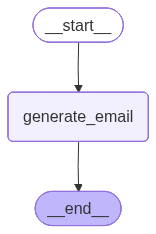

In [47]:
# generate a graph

graph = StateGraph(GraphState)

# add node to graph
graph.add_node("generate_email",generate_email)
# //add edge

graph.add_edge(START, "generate_email")
graph.add_edge("generate_email",END)
checkpointer =MemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [48]:
config = {"configurable": {"thread_id": '1234'}}
initial_state={'query':"Generate an email  for regarding the short leave application"}



result = workflow.invoke(initial_state,config=config)
result

{'query': 'Generate an email  for regarding the short leave application',
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about  to answer  a user question', 'email': "Subject: Application for Short Leave\n\nDear [Manager's Name],\n\nI hope this email finds you well.\n\nI am writing to request a short leave of absence for the following dates: [Start Date] to [End Date].\n\nThe reason for my leave is [brief explanation, e.g., personal/caregiving reasons, medical appointments, etc.]. I aim to use this time to [mention any specific activities, e.g., rest, attend to personal matters, etc.].\n\nI have scheduled my leave during a period that should minimize any disruption to the team’s workflow. My current responsibilities will be completed by [colleague's name], and they will ensure all tasks are on track. I will also be available via email and phone if any urgent issues arise.\n\nI have reviewed our company policy and I believe I meet the requirements for this t

In [49]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about  to answer  a user question',
 'email': "Subject: Application for Short Leave\n\nDear [Manager's Name],\n\nI hope this email finds you well.\n\nI am writing to request a short leave of absence for the following dates: [Start Date] to [End Date].\n\nThe reason for my leave is [brief explanation, e.g., personal/caregiving reasons, medical appointments, etc.]. I aim to use this time to [mention any specific activities, e.g., rest, attend to personal matters, etc.].\n\nI have scheduled my leave during a period that should minimize any disruption to the team’s workflow. My current responsibilities will be completed by [colleague's name], and they will ensure all tasks are on track. I will also be available via email and phone if any urgent issues arise.\n\nI have reviewed our company policy and I believe I meet the requirements for this type of leave. I am committed to ensuring that my absence will not affect our projects or team operations.\n

In [54]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")
if user_input:
    final_result=workflow.invoke(Command(resume={"approved":user_input}), config=config),
   
    print(final_result)

({'query': 'Generate an email  for regarding the short leave application', 'messages': [AIMessage(content='Not approved', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]},)
